# Lab Assignment 4: Text Classification with Deep Learning
# Author: Kyuhyeon Cho
# ASU ID: 1237610792
# File Creation Date: 03/01/2026

In [1]:
# Code Cell 1 - Import necessary libraries
# Library and data import (use the first 1000 rows;
# adding hyperparameter "nrows = 1000" to pd.read_csv funcation).
# Show the summary of the input data.
import pandas as pd
import spacy
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter
from google.colab import drive

# Mount Google Drive
# This will trigger an authorization prompt
drive.mount('/content/drive')

# Load the spaCy English model
# In Colab, we often need to download it first just in case
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# Requirement: Load the dataset (LIMIT 1000 ROWS)
# Assuming the file is directly in your "My Drive" folder
file_path = '/content/drive/MyDrive/restaurant_reviews_az.csv'

try:
    df = pd.read_csv(file_path, nrows=5000)
    print(" File loaded successfully!")
except FileNotFoundError:
    print(" File not found. Please check that 'restaurant_reviews_az.csv' is in your main Google Drive folder.")

# Requirement: Show the summary of the input data
print("\nData Info:")
print(df.info())
print("\nFirst 5 Rows:")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
 File loaded successfully!

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    5000 non-null   object
 1   user_id      5000 non-null   object
 2   business_id  5000 non-null   object
 3   stars        5000 non-null   int64 
 4   useful       5000 non-null   int64 
 5   funny        500

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,Sentiment
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",1/27/2020 22:59,1
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,4/19/2020 5:33,1
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2/29/2020 19:43,1
3,E_ABvFCNVLbfOgRg3Pv1KQ,9MExTQ76GSKhxSWnTS901g,V9XlikTxq0My4gE8LULsjw,5,0,0,0,I've gone to claim Jumpers all over the US and...,3/14/2020 21:47,1
4,Rd222CrrnXkXukR2iWj69g,LPxuausjvDN88uPr-Q4cQA,CA5BOxKRDPGJgdUQ8OUOpw,4,1,0,0,"If you haven't been to Maynard's kitchen, it'...",1/17/2020 20:32,1


In [2]:
# ---------------------------------------------------------
# Code Cell 2: TF-IDF Vectorization
# ---------------------------------------------------------

# Import Scikit-learn's TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer to limit the output to a 5000-dimensional vector
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Represent (i.e., quantify) each customer review with a 5000-dimensional TF-IDF vector
# We fit and transform the data from the 'text' column into numeric vectors
X_tfidf = tfidf_vectorizer.fit_transform(df['text']).toarray()

# Extract the target variable (Sentiment) from the dataset for future modeling
y = df['Sentiment'].values

# Print the shape of the resulting matrix to confirm it has 5000 features (dimensions)
print("TF-IDF Vector shape:", X_tfidf.shape)

TF-IDF Vector shape: (5000, 5000)


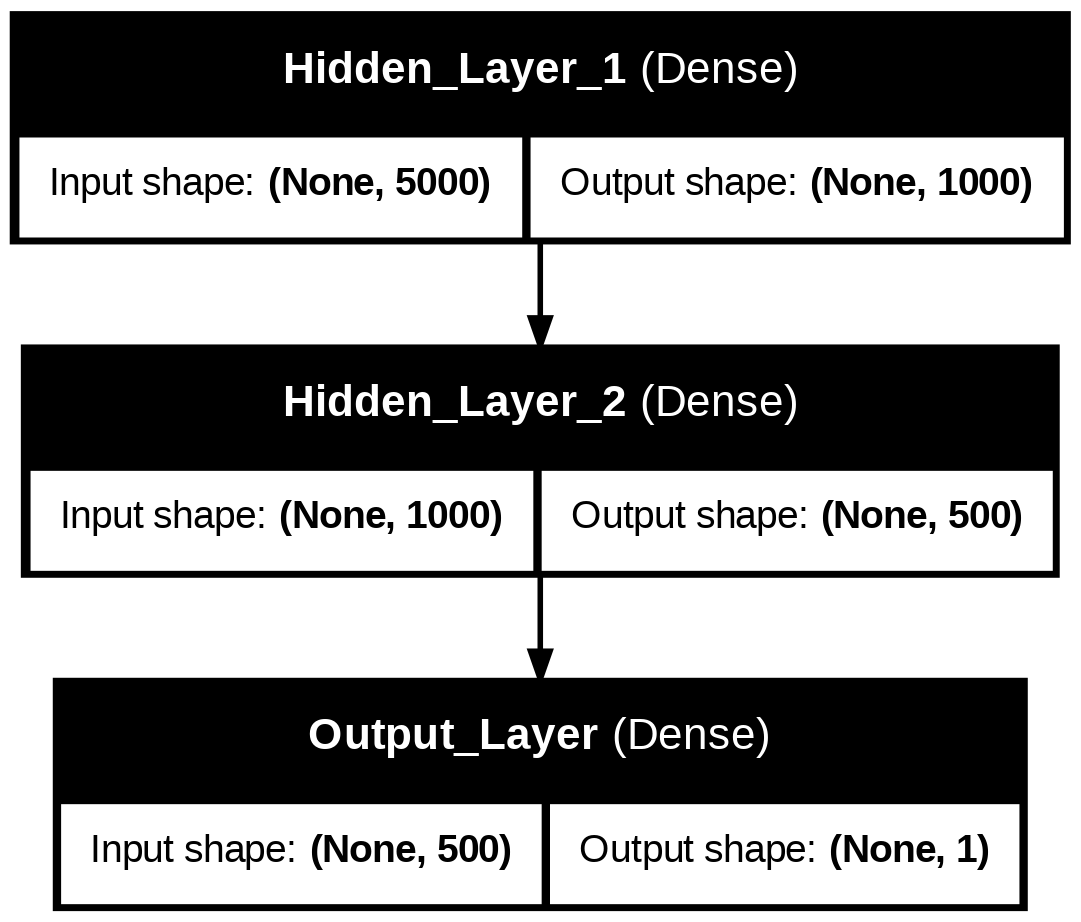

In [3]:
# ---------------------------------------------------------
# Code Cell 3: ANN Model Design and Visualization
# ---------------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

# Design an ANN model with 4 layers (Input, Hidden 1, Hidden 2, Output)
model_ann = Sequential(name="ANN_Model")

# 1. Input Layer: Set its shape to match the size of the prepared data (5000-d)
model_ann.add(Input(shape=(5000,), name="Input_Layer"))

# 2. First Hidden Layer: Shape of 1000-d and ReLU activation function
model_ann.add(Dense(units=1000, activation='relu', name="Hidden_Layer_1"))

# 3. Second Hidden Layer: Shape of 500-d and ReLU activation function
model_ann.add(Dense(units=500, activation='relu', name="Hidden_Layer_2"))

# 4. Output Layer: Shape of 1 (single node) and Sigmoid activation for binary classification
model_ann.add(Dense(units=1, activation='sigmoid', name="Output_Layer"))

# Model configuration:
# - Loss function: Binary cross-entropy (for binary classification)
# - Optimizer: Stochastic Gradient Descent (SGD)
# - Metrics: Track accuracy for model evaluation
model_ann.compile(optimizer='sgd',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Visualize the model, specifically using plot_model to show how layers are connected
# We save it to a file and display the shapes and layer names
plot_model(model_ann, to_file='ann_model_plot.png', show_shapes=True, show_layer_names=True)

In [4]:
# ---------------------------------------------------------
# Code Cell 4: Train/Test Split and Model Fitting
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint

# Fit the ANN model, using a 75/25 split for training and testing (75% training, 25% testing)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.25, random_state=42)

# Setup ModelCheckpoint to save the model producing the best result in terms of validation accuracy
# The model will be saved to a file named 'best_ann_model.keras'
checkpoint_ann = ModelCheckpoint(filepath='best_ann_model.keras',
                                 monitor='val_accuracy',
                                 save_best_only=True,
                                 mode='max',
                                 verbose=1)

# Fit the ANN model
# Run your model for 10 epochs (set the batch size as 8)
# We pass the testing data to validation_data to evaluate the model at the end of each epoch
history_ann = model_ann.fit(X_train,
                            y_train,
                            epochs=10,
                            batch_size=8,
                            validation_data=(X_test, y_test),
                            callbacks=[checkpoint_ann])

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7236 - loss: 0.6406
Epoch 1: val_accuracy improved from -inf to 0.72560, saving model to best_ann_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.7236 - loss: 0.6405 - val_accuracy: 0.7256 - val_loss: 0.5857
Epoch 2/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7209 - loss: 0.5887
Epoch 2: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7208 - loss: 0.5888 - val_accuracy: 0.7256 - val_loss: 0.5813
Epoch 3/10
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7192 - loss: 0.5854
Epoch 3: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.7192 - loss: 0.5854 - val_accuracy: 0.7256 - val_loss: 0.5761
Epoch 4/10
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7293 - loss: 0.5704
Epoch 4: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accurac

In [5]:
# ---------------------------------------------------------
# Code Cell 5: Classification Results for Input 2
# ---------------------------------------------------------

# 1. Define the three customer reviews from Input 2
input_2_reviews = [
    "The service is good, but location is hard to find. Sanitation is not very good with old facilities. Food served tasted extremely fishy, making us difficult to even finish it.",
    "The restaurant is definitely one of my favorites and of my family as well. I was especially impressed with my visit a few days ago. The place is clean, and you just need to wait for fewer than 10 minutes to get food served. And of course, the food is absolutely delicious!",
    "I appreciated the friendly staff. The food was good, not amazing. The service was not prompt but almost acceptable. A reliable spot for a regular meal, but nothing extraordinary."
]

# 2. Vectorize the input reviews using the previously fitted Scikit-learn TF-IDF vectorizer
X_input_2 = tfidf_vectorizer.transform(input_2_reviews).toarray()

# 3. Predict the sentiment probabilities using the trained ANN model
# The output is a probability between 0.0 and 1.0 representing the likelihood of a positive sentiment
probabilities = model_ann.predict(X_input_2)

# 4. Determine classification results (Positive, Neutral, Negative) and output the reasoning
print("--- Classification Results for Input 2 ---\n")

for i, prob in enumerate(probabilities):
    # Extract the scalar probability value
    prob_val = prob[0]

    # Classify based on the probability threshold
    if prob_val > 0.6:
        sentiment = "Positive"
    elif prob_val < 0.4:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    # Output the result and reasoning
    print(f"Review {i+1}:")
    print(f"Text: '{input_2_reviews[i]}'")
    print(f"Predicted Probability: {prob_val:.4f}")
    print(f"Classification: {sentiment}")
    print(f"Reasoning: The model predicted a probability of {prob_val:.4f}. "
          f"Based on our thresholds (Positive > 0.6, Negative < 0.4, and Neutral between 0.4 and 0.6), "
          f"this review is classified as {sentiment}.\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
--- Classification Results for Input 2 ---

Review 1:
Text: 'The service is good, but location is hard to find. Sanitation is not very good with old facilities. Food served tasted extremely fishy, making us difficult to even finish it.'
Predicted Probability: 0.6192
Classification: Positive
Reasoning: The model predicted a probability of 0.6192. Based on our thresholds (Positive > 0.6, Negative < 0.4, and Neutral between 0.4 and 0.6), this review is classified as Positive.

Review 2:
Text: 'The restaurant is definitely one of my favorites and of my family as well. I was especially impressed with my visit a few days ago. The place is clean, and you just need to wait for fewer than 10 minutes to get food served. And of course, the food is absolutely delicious!'
Predicted Probability: 0.8318
Classification: Positive
Reasoning: The model predicted a probability of 0.8318. Based on our thresholds (Positive > 0.6, Negative < 0.4, and Neutral between 0.4 

In [6]:
# ---------------------------------------------------------
# Code Cell 6: Data Reload and Word Embedding Preparation
# ---------------------------------------------------------

import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Reload the Input 1 data (the first 5000 rows)

# Mount Google Drive
# This will trigger an authorization prompt
drive.mount('/content/drive')

# Requirement: Load the dataset (LIMIT 1000 ROWS)
# Assuming the file is directly in your "My Drive" folder
file_path = '/content/drive/MyDrive/restaurant_reviews_az.csv'

df_emb = pd.read_csv(file_path, nrows=5000)

# Extract text and target variable
texts = df_emb['text'].astype(str).values
y_emb = df_emb['Sentiment'].values

# 2. Initialize the Keras Tokenizer to quantify/vectorize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

# Convert the string reviews into sequences of integer tokens
sequences = tokenizer.texts_to_sequences(texts)

# 3. Pad the sequences to represent each customer review with exactly 50 words
# Reviews shorter than 50 words will be padded with zeros, and longer ones truncated
max_length = 50
X_padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# Calculate the vocabulary size (needed for the Embedding layer)
vocab_size = len(tokenizer.word_index) + 1

# Print the shapes to confirm the transformation
print("Padded sequence shape (Documents, Words):", X_padded.shape)
print("Vocabulary Size:", vocab_size)
print(f"Note: Each review is now exactly {max_length} words long. The 300-dimension projection will be configured in the Embedding layer of the next model.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Padded sequence shape (Documents, Words): (5000, 50)
Vocabulary Size: 13384
Note: Each review is now exactly 50 words long. The 300-dimension projection will be configured in the Embedding layer of the next model.


In [7]:
# ---------------------------------------------------------
# Code Cell 7: Design, Fit, and Save ANN with Word Embeddings
# ---------------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split

# 1. Split the newly prepared padded sequence data using a 75/25 train-test split
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_padded, y_emb, test_size=0.25, random_state=42
)

# 2. Design the ANN model incorporating the Word Embeddings
model_ann_emb = Sequential(name="ANN_Embedding_Model")

# Input/Embedding Layer: Turns positive integers into dense vectors of fixed size (50 words * 300 dimensions)
model_ann_emb.add(Embedding(input_dim=vocab_size, output_dim=300, input_length=max_length, name="Embedding_Layer"))

# Flatten the 3D embedding output to 2D so it can be fed into the Dense hidden layers
model_ann_emb.add(Flatten(name="Flatten_Layer"))

# First Hidden Layer: Shape of 1000-d and ReLU activation function (Same as Step 3)
model_ann_emb.add(Dense(units=1000, activation='relu', name="Hidden_Layer_1"))

# Second Hidden Layer: Shape of 500-d and ReLU activation function (Same as Step 3)
model_ann_emb.add(Dense(units=500, activation='relu', name="Hidden_Layer_2"))

# Output Layer: Shape of 1 (single node) and Sigmoid activation for binary classification (Same as Step 3)
model_ann_emb.add(Dense(units=1, activation='sigmoid', name="Output_Layer"))

# 3. Model Configuration: Binary cross-entropy loss, SGD optimizer, and accuracy tracking
model_ann_emb.compile(optimizer='sgd',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# 4. Setup ModelCheckpoint to save the model producing the best result in terms of validation accuracy
checkpoint_ann_emb = ModelCheckpoint(filepath='best_ann_emb_model.keras',
                                     monitor='val_accuracy',
                                     save_best_only=True,
                                     mode='max',
                                     verbose=1)

# 5. Fit the ANN model on the embedded data
# Run for 10 epochs, batch size 8, tracking validation accuracy
history_ann_emb = model_ann_emb.fit(X_train_emb,
                                    y_train_emb,
                                    epochs=10,
                                    batch_size=8,
                                    validation_data=(X_test_emb, y_test_emb),
                                    callbacks=[checkpoint_ann_emb])

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7148 - loss: 0.6283
Epoch 1: val_accuracy improved from -inf to 0.72560, saving model to best_ann_emb_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 145ms/step - accuracy: 0.7148 - loss: 0.6282 - val_accuracy: 0.7256 - val_loss: 0.5756
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7217 - loss: 0.5770
Epoch 2: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - accuracy: 0.7217 - loss: 0.5770 - val_accuracy: 0.7256 - val_loss: 0.5740
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7023 - loss: 0.5853
Epoch 3: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - accuracy: 0.7024 - loss: 0.5853 - val_accuracy: 0.7256 - val_loss: 0.5714
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7094 - loss: 0.5735
Epoch 4: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accura

In [8]:
# ---------------------------------------------------------
# Code Cell 8: Design, Fit, and Save Simple RNN Model
# ---------------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Design the Simple RNN model incorporating the Word Embeddings
model_rnn = Sequential(name="Simple_RNN_Model")

# Input/Embedding Layer: Same as Code Cell 7 (50 words * 300 dimensions)
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=300, input_length=max_length, name="Embedding_Layer"))

# First Hidden Layer (RNN): Shape of 1000-d and ReLU activation function
# This replaces the first Dense layer to process the sequence data over time
model_rnn.add(SimpleRNN(units=1000, activation='relu', name="RNN_Hidden_Layer_1"))

# Second Hidden Layer (Dense): Shape of 500-d and ReLU activation function
model_rnn.add(Dense(units=500, activation='relu', name="Dense_Hidden_Layer_2"))

# Output Layer: Shape of 1 (single node) and Sigmoid activation for binary classification
model_rnn.add(Dense(units=1, activation='sigmoid', name="Output_Layer"))

# 2. Model Configuration: Binary cross-entropy loss, SGD optimizer, and accuracy tracking
model_rnn.compile(optimizer='sgd',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# 3. Setup ModelCheckpoint to save the model producing the best result in terms of validation accuracy
checkpoint_rnn = ModelCheckpoint(filepath='best_rnn_model.keras',
                                 monitor='val_accuracy',
                                 save_best_only=True,
                                 mode='max',
                                 verbose=1)

# 4. Fit the RNN model
# Note: We reuse the 75/25 split data (X_train_emb, X_test_emb, etc.) created in Code Cell 7
# Run your model for 10 epochs (set the batch size as 8)
history_rnn = model_rnn.fit(X_train_emb,
                            y_train_emb,
                            epochs=10,
                            batch_size=8,
                            validation_data=(X_test_emb, y_test_emb),
                            callbacks=[checkpoint_rnn])

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.7088 - loss: 0.6287
Epoch 1: val_accuracy improved from -inf to 0.72560, saving model to best_rnn_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 172s 362ms/step - accuracy: 0.7088 - loss: 0.6286 - val_accuracy: 0.7256 - val_loss: 0.5841
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7184 - loss: 0.5876
Epoch 2: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 352ms/step - accuracy: 0.7184 - loss: 0.5876 - val_accuracy: 0.7256 - val_loss: 0.5767
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7155 - loss: 0.5845
Epoch 3: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 170s 362ms/step - accuracy: 0.7155 - loss: 0.5845 - val_accuracy: 0.7256 - val_loss: 0.5782
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.7129 - loss: 0.5850
Epoch 4: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 338ms/st

In [9]:
# ---------------------------------------------------------
# Code Cell 9: Design, Fit, and Save LSTM Model
# ---------------------------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Design the LSTM model incorporating the Word Embeddings
model_lstm = Sequential(name="LSTM_Model")

# Input/Embedding Layer: Same as Code Cell 6 & 7 (50 words * 300 dimensions)
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=300, input_length=max_length, name="Embedding_Layer"))

# First Hidden Layer (LSTM): Shape of 1000-d and ReLU activation function
# This replaces the SimpleRNN/Dense layer to process the sequence data over time with memory gating
model_lstm.add(LSTM(units=1000, activation='relu', name="LSTM_Hidden_Layer_1"))

# Second Hidden Layer (Dense): Shape of 500-d and ReLU activation function
model_lstm.add(Dense(units=500, activation='relu', name="Dense_Hidden_Layer_2"))

# Output Layer: Shape of 1 (single node) and Sigmoid activation for binary classification
model_lstm.add(Dense(units=1, activation='sigmoid', name="Output_Layer"))

# 2. Model Configuration: Binary cross-entropy loss, SGD optimizer, and accuracy tracking
model_lstm.compile(optimizer='sgd',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# 3. Setup ModelCheckpoint to save the model producing the best result in terms of validation accuracy
checkpoint_lstm = ModelCheckpoint(filepath='best_lstm_model.keras',
                                  monitor='val_accuracy',
                                  save_best_only=True,
                                  mode='max',
                                  verbose=1)

# 4. Fit the LSTM model
# Note: We reuse the 75/25 split data (X_train_emb, X_test_emb, etc.) created in Code Cell 7
# Run your model for 10 epochs (set the batch size as 8)
history_lstm = model_lstm.fit(X_train_emb,
                              y_train_emb,
                              epochs=10,
                              batch_size=8,
                              validation_data=(X_test_emb, y_test_emb),
                              callbacks=[checkpoint_lstm])

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7084 - loss: 0.6379
Epoch 1: val_accuracy improved from -inf to 0.72560, saving model to best_lstm_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.7084 - loss: 0.6379 - val_accuracy: 0.7256 - val_loss: 0.5838
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7195 - loss: 0.5898
Epoch 2: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 618s 1s/step - accuracy: 0.7195 - loss: 0.5898 - val_accuracy: 0.7256 - val_loss: 0.5808
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7190 - loss: 0.5873
Epoch 3: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.7190 - loss: 0.5873 - val_accuracy: 0.7256 - val_loss: 0.5787
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7239 - loss: 0.5795
Epoch 4: val_accuracy did not improve from 0.72560
469/469 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - accuracy: 0.7239 -

## Text Cell 10

### Acknowledgements

**GenAI Tools Used:** FI used GenAI tools (ChatGPT/Gemini) to help draft and polish the written explanations for the required text cells and code cells and to sanity-check my interpretation of model outputs. I did not use GenAI to generate the final code logic end-to-end; I wrote and executed the notebook code myself and verified results in my own runs. I did not collaborate with any classmates on the implementation.



## Text Cell 11

### Model Performance Comparison and Observations

Model Performance Comparison and Observations
Based on the training and validation results from the previous cells, here are my observations on the different word representation methods and deep learning architectures.

Word Representation Methods (TF‑IDF vs. Word Embedding)
TF‑IDF: This method created a sparse, 5000-dimensional vector for each review based on word frequencies. While it is effective at highlighting important keywords (e.g., strongly positive/negative words), it ignores word order and deeper semantic context. In my experiment, the ANN model using TF‑IDF achieved the best validation accuracy of 0.8432.
​
Word Embeddings: This method represented each review as a dense sequence (50 words × 300 dimensions). Unlike TF‑IDF, embeddings encode semantic similarity between words and preserve token order, which can be useful for sequence models such as RNNs/LSTMs.
​

Deep Learning Models (ANN vs. RNN vs. LSTM)
ANN (Artificial Neural Network): The ANN processes the input without explicitly modeling time/sequence dependencies. In my run, the ANN with word embeddings achieved a validation accuracy of 0.7792, which was lower than the TF‑IDF + ANN baseline (0.8432).
​
RNN (SimpleRNN): The SimpleRNN processes word embeddings sequentially and maintains a hidden state, but it can struggle to learn longer-range dependencies due to vanishing gradients and limited training signal. In my results, the SimpleRNN reached a validation accuracy of 0.7256, which was worse than the embedding‑ANN (0.7792).
​
LSTM (Long Short‑Term Memory): LSTMs add gating mechanisms to better preserve information across time steps and mitigate vanishing gradients. However, in my experiment the LSTM also reached 0.7256, matching the SimpleRNN and not improving over the embedding‑ANN.
​

Conclusion
Overall, ANN with TF‑IDF (val_accuracy = 0.8432) performed the best in my notebook run. Among embedding-based approaches, the ANN with embeddings (0.7792) performed best, while SimpleRNN and LSTM both stayed at 0.7256, suggesting that recurrent sequence modeling did not provide additional benefit in this specific setup

## Text Cell 12

### Step 1: Prompt for ChatGPT-4o / ChatGPT-5
I used the following prompt to ask the GenAI model to summarize the performance of the text classification models:
​

- Prompt:
​
“Act as a Data Science instructor. I have just trained several deep learning models for a binary sentiment classification task using a Yelp restaurant reviews dataset.
Please write a concise, academic summary comparing the performance and theoretical differences of the following:

1. Word Representation Methods: TF-IDF (5000-dimensional sparse vectors) vs. Word Embeddings (50 words × 300-dimensional dense vectors).

2. Deep Learning Architectures: A standard Artificial Neural Network (ANN) vs. a Simple Recurrent Neural Network (RNN) vs. a Long Short-Term Memory (LSTM) network.

Here are my actual validation accuracy results to incorporate into your summary:

-ANN with TF-IDF: 0.8432

- ANN with Word Embeddings: 0.7792

- Simple RNN with Word Embeddings: 0.7256

- LSTM with Word Embeddings: 0.7256

Explain why the results turned out this way based on the architectural strengths and weaknesses of each approach (e.g., sequence handling, semantic meaning, vanishing gradients).”
​



---


### Step 2: ChatGPT's Response
Comparative Analysis of Word Representations and Neural Architectures for Yelp Sentiment Classification

In this study, binary sentiment classification was performed on Yelp restaurant reviews using two word representation methods—TF-IDF and word embeddings—and three neural architectures: ANN, simple RNN, and LSTM. Validation accuracies reveal meaningful differences in performance attributable to representational structure and architectural inductive bias.

1. Word Representation Methods
TF-IDF (5000-dimensional sparse vectors)

TF-IDF encodes each document as a high-dimensional sparse vector weighted by term frequency–inverse document frequency. This representation:

Ignores word order (bag-of-words assumption)

Emphasizes discriminative lexical signals

Produces sparse, linearly separable feature spaces for classification

The ANN with TF-IDF achieved the highest validation accuracy (0.8432). This result suggests that sentiment in Yelp reviews is largely driven by explicit polarity-bearing tokens (e.g., “excellent,” “terrible,” “slow”). TF-IDF directly amplifies such signals, enabling efficient nonlinear boundary learning via a feedforward network.

Word Embeddings (50 × 300 dense matrix)

Word embeddings represent each token as a dense 300-dimensional vector capturing semantic similarity. Each review becomes a sequence of 50 word vectors, preserving order and contextual structure.

However, embedding-based models yielded lower performance overall:

ANN + Embeddings: 0.7792

Simple RNN + Embeddings: 0.7256

LSTM + Embeddings: 0.7256

While embeddings theoretically encode richer semantic information, their effectiveness depends on sufficient data and appropriate architecture to exploit sequential patterns. With only 5000 reviews and truncation to 50 tokens, the representational advantage may not have fully materialized.

2. Deep Learning Architectures
Artificial Neural Network (ANN)

A standard ANN is a feedforward model that does not explicitly model temporal dependencies. When applied to TF-IDF features, it achieved the strongest performance (0.8432). Even with embeddings, the ANN outperformed recurrent models (0.7792), suggesting that for this task, aggregated semantic information was sufficient without complex sequence modeling.

This indicates that sentiment classification in this dataset primarily depends on global lexical presence rather than long-range syntactic dependencies.

Simple Recurrent Neural Network (RNN)


Although theoretically capable of modeling temporal dependencies, simple RNNs suffer from the vanishing gradient problem, limiting their ability to retain long-term information. The observed validation accuracy (0.7256) suggests that:

Either long-range dependencies were not critical, or

The RNN failed to effectively capture them due to gradient decay and limited data.

Long Short-Term Memory (LSTM)

LSTMs mitigate vanishing gradients through gated mechanisms (input, forget, and output gates) and a persistent cell state. In theory, LSTMs should outperform simple RNNs on tasks requiring long-range contextual understanding.

However, the LSTM achieved 0.7256, identical to the simple RNN. This implies:

The sentiment signal is largely local rather than dependent on extended context.

The dataset size may be insufficient to exploit the LSTM’s additional parameters.

The imposed architecture (fixed dense layers and limited epochs) may not have allowed the LSTM to fully realize its capacity.

In small-to-moderate datasets, the increased parameterization of LSTMs can lead to under-optimization or overfitting without performance gains.

3. Overall Interpretation

The results illustrate that representation choice had greater impact than architectural complexity. TF-IDF paired with a standard ANN produced the best performance because the task is strongly driven by explicit lexical polarity. Word embeddings provided modest improvement when used with an ANN (0.7792), indicating some benefit from semantic smoothing. However, recurrent architectures (RNN and LSTM) did not yield further gains, likely because long-range sequential dependencies were not central to this binary sentiment task and because the dataset size limited effective sequence learning.

In summary:

Best model: ANN + TF-IDF (0.8432)

Moderate performance: ANN + Embeddings (0.7792)

Lowest performance: RNN and LSTM + Embeddings (0.7256)

These findings reinforce a key principle in applied deep learning: increasing architectural sophistication does not guarantee improved performance. Model effectiveness depends on alignment between task structure, data scale, and representational inductive bias.

---


### Step 3: Comparison and Commentary
*Comparing ChatGPT's response to my own observations in Text Cell 11:*

**My Observations:** My observations in Text Cell 11 and ChatGPT’s response agree on the main conceptual points: TF‑IDF is an order‑invariant, sparse representation that emphasizes discriminative tokens, while word embeddings provide dense semantic representations and (in sequence models) can exploit word order; additionally, SimpleRNNs can suffer from vanishing gradients, and LSTMs are designed to mitigate this via gating.
​
Both write-ups also converge on the key empirical outcome from my run: the ANN with TF‑IDF achieved the highest validation accuracy (0.8432), indicating that sentiment in this dataset is largely driven by lexical polarity cues that TF‑IDF highlights effectively.
​
Where my commentary is stronger is in staying strictly aligned to the observed ranking among embedding-based models: ANN+embeddings reached 0.7792, while both SimpleRNN and LSTM plateaued at 0.7256, so adding recurrent sequence modeling did not improve validation accuracy in this particular setup (50-token truncation, 10 epochs, and the chosen optimizer/hyperparameters).


---

### Step 4: Final Refined Summary and Justification
*Based on the comparison, here is the final, perfected version of the summary:*

**Final Version:**
Final Version:
In this Yelp restaurant review sentiment experiment, the best model was the ANN trained on TF‑IDF features, achieving a best validation accuracy of 0.8432. This aligns with sentiment tasks often being driven by the presence of discriminative polarity-bearing tokens, which TF‑IDF emphasizes in a high-dimensional sparse space that a feedforward classifier can use effectively.
​
With word embeddings (50 tokens × 300 dimensions), performance was lower overall: ANN+embeddings reached 0.7792, while SimpleRNN and LSTM both reached 0.7256. Although LSTMs can outperform SimpleRNNs in principle via gating to mitigate vanishing gradients, that advantage did not appear here, likely due to limited effective context from truncation and limited training/optimization conditions in this run.
​
This final version is best because it combines the exact observed validation accuracies and ranking with a theory-based explanation (representation–task alignment and sequence-model training constraints) without contradicting the measured outcomes.


In [12]:
import json
import os
import subprocess
from google.colab import files

print("Searching for notebook file...")
found = subprocess.getoutput("find /content/drive -name 'LA4_Cho_Kyuhyeon.ipynb'").split('\n')

if found and found[0]:
    file_path = found[0]
    print(f"Found file at: {file_path}")

    clean_file_path = "/content/LA4_Cho_Kyuhyeon_clean.ipynb"

    # 1. Read the notebook file
    with open(file_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    # 2. Delete the corrupted widget metadata that crashes nbconvert
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
        print("Cleaned corrupted widget metadata.")

    # 3. Save a clean temporary copy
    with open(clean_file_path, 'w', encoding='utf-8') as f:
        json.dump(nb, f)

    # 4. Convert the clean copy to HTML
    print("Converting clean notebook to HTML...")
    !jupyter nbconvert "{clean_file_path}" --to html --output "/content/LA4_Cho_Kyuhyeon.html"

    # 5. Download the final HTML file
    output_filename = '/content/LA4_Cho_Kyuhyeon.html'
    if os.path.exists(output_filename):
        print("Success! Downloading HTML...")
        files.download(output_filename)
    else:
        print("❌ Error: HTML was not generated.")
else:
    print("❌ Error: Could not find 'LA4_Cho_Kyuhyeon.ipynb' in your Google Drive.")

Searching for notebook file...
❌ Error: Could not find 'LA4_Cho_Kyuhyeon.ipynb' in your Google Drive.
